# Ajuste de gaussianas en picos dQdV - parte 2

In [27]:
from pathlib import Path
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
import func_deriv as func_deriv
import func_plots as func_plots
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

In [28]:
# %% ------- Cargar ciclos ------------------------------------------------------------
input_folder = Path('/home/mariajose/proc-icdv/tmp')
nombre_archivo = "NMC-20"
output_folder = Path('/home/mariajose/proc-icdv/output')
output_folder.mkdir(parents=True, exist_ok=True)  # Create output directory if it doesn't exist

with open(input_folder / f'{nombre_archivo}.json') as f_json:
    raw_dict = json.load(f_json)

dict_ciclos_sep = {
    int(ciclo): {
        etapa: pd.DataFrame(data) for etapa, data in etapas.items()
    }
    for ciclo, etapas in raw_dict.items()
}

indices_ciclos = list(dict_ciclos_sep.keys())

In [29]:
# %% ------- Elegir ciclos ------------------------------------------------------------

# Elijo en todo el rango, equiespaciados
N_ciclos = 10  # Número de ciclos a tomar, si no se especifica, toma todos los del archivo
indices_ciclos_ = indices_ciclos[:-1] # Quito el último
indices_ciclos_array = np.array(indices_ciclos_)
ciclos_disponibles = sorted(dict_ciclos_sep.keys())
ciclos_seleccionados = indices_ciclos_array[np.linspace(0, len(indices_ciclos_array)-1, N_ciclos, dtype=int)]
#print("Ciclos seleccionados:", ciclos_seleccionados)
#print(f"son {len(ciclos_seleccionados)} ciclos")

# Elecciones manuales
#ciclos_reducidos = [3, 21, 78, 153, 228, 303, 378, 453, 528, 603, 678, 753, 828]
#ciclos_seleccionados = [2, 99, 192, 300, 414, 504, 600, 702, 801, 897]
ciclos_seleccionados = [2, 21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
ciclos_seleccionados = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]


excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900} # ciclos feos
ciclos_seleccionados = [c for c in ciclos_disponibles if 21 <= c <= 900 and c not in excluir]

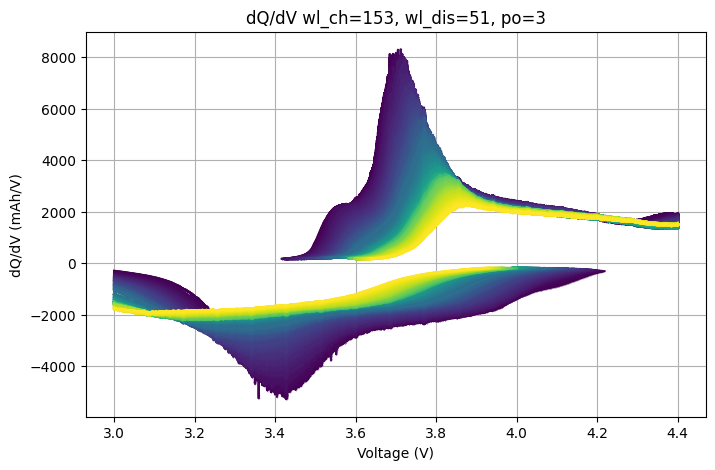

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...\n        }\n"

In [30]:
# %% ------- Trunco datos y calculo derivada ------------------------------------------------------------

# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

diccio = func_deriv.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)
diccio =  func_deriv.plot_dqdv(ciclos_seleccionados, diccio, legend=False)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...
        }
'''

In [31]:
# %% ------- Defino funciones ajuste ------------------------------------------------------------

def multi_gauss(x, *params):
    """
    params: [a1, mu1, sigma1, a2, mu2, sigma2, ..., an, mun, sigman]
    """
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        a, mu, sigma = params[i:i+3]
        y += a * np.exp(-(x-mu)**2 / (2*sigma**2))
    return y


def gauss(x, a, mu, sigma):
    return a * np.exp(-(x-mu)**2 / (2*sigma**2))

### Pruebo con un ciclo

In [54]:
# %% ------- Parámetros iniciales ------------------------------------------------------------

# ------ Elegir cuál ciclo y de qué loop tomar los parametros anteriores ---------------
ciclo_anterior = 300
n_peaks_anterior = 5
df_anterior = pd.read_csv("./output/parametros_ajustes_moreSteps-10bounds.csv", index_col=0)
nombre = '' # etiqueta gráfico
# --------------------------------------------------------------------------------

coef_inf = 0.5
coef_sup = 1.5

# Tomo como parametros iniciales y bounds el ajuste del ciclo anterior
loc = df_anterior.index.get_loc(ciclo_anterior)   # posición del ciclo dentro del DataFrame
parametros = df_anterior.loc[ciclo_anterior].values
popt = parametros[:n_peaks_anterior*3]   # me quedo con a, mu, sigma

print(parametros)
print(popt)
print(n_peaks)

lb = []
ub = []
for i in range(n_peaks_anterior):
    a0, mu0, sigma0 = popt[3*i:3*i+3]
    lb += [coef_inf*a0, coef_inf*mu0, coef_inf*sigma0]
    ub += [coef_sup*a0, coef_sup*mu0, coef_sup*sigma0]

p_ini = popt
bounds_ini = (lb, ub)

# ---------- Excluyo picos que ya se fueron a cero -------------------------------
picos_excluidos = []  # poner el índice de los picos que se quieren excluir: 1, 2, 3, 4 o 5

p_ini_filtrado = []
lb = []
ub = []

for i in range(n_peaks_anterior):
    if (i+1) in picos_excluidos:
        continue  # no lo meto en el ajuste
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    p_ini_filtrado += [a0, mu0, sigma0]
    lb += [coef_inf*a0, coef_inf*mu0, coef_inf*sigma0]
    ub += [coef_sup*a0, coef_sup*mu0, coef_sup*sigma0]

bounds_ini_filtrado = (lb, ub)

#print(p_ini)
#print(p_ini_filtrado)

[3.31210154e+02 3.62697676e+00 3.43010547e-02 1.87485155e+03
 3.76668494e+00 3.76581868e-02 1.98066448e+03 3.78191350e+00
 8.97829135e-02 1.42329405e+03 3.97098059e+00 1.89188882e-01
 1.26252097e+03 4.36098560e+00 2.97967533e-01 2.84774469e+01
 1.76976755e+02 4.45753274e+02 6.74963328e+02 9.42969141e+02]
[3.31210154e+02 3.62697676e+00 3.43010547e-02 1.87485155e+03
 3.76668494e+00 3.76581868e-02 1.98066448e+03 3.78191350e+00
 8.97829135e-02 1.42329405e+03 3.97098059e+00 1.89188882e-01
 1.26252097e+03 4.36098560e+00 2.97967533e-01]
5


len(popt): 15
popt: [3.05749530e+02 3.62581520e+00 2.38596890e-02 1.04269751e+03
 3.76246463e+00 2.26397883e-02 2.41561102e+03 3.76674551e+00
 6.27890045e-02 1.17760793e+03 3.87241364e+00 1.42287302e-01
 1.64110556e+03 4.18798990e+00 3.05026078e-01]


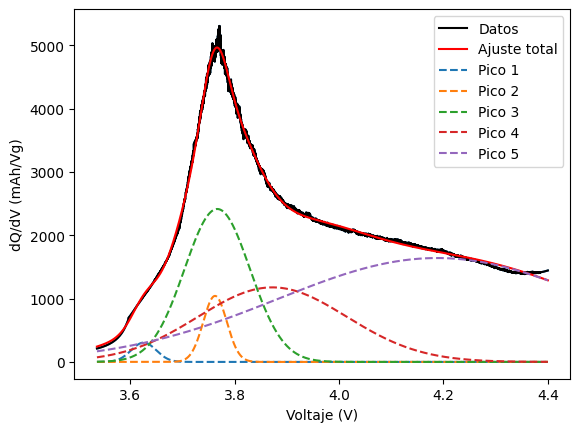

In [55]:
# %% ------- Pruebo ajustar un ciclo particular ------------------------------------------------------------

# ------ Elegir cuál  ---------------
ciclo = 303
nombre = '' # etiqueta gráfico
# -----------------------------------

df_ch = diccio[ciclo]['Ch']
df_dis = diccio[ciclo]['Dis']
dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol']

plt.plot(V, dqdv_ch_calc)
colors_peaks = cm.tab10.colors

p0_actual = p_ini_filtrado
bounds_actual = bounds_ini_filtrado

# Ajuste
popt, pcov = curve_fit(multi_gauss, V, dqdv_ch_calc, p0=p0_actual, bounds=bounds_actual, maxfev=20000   # por defecto suele ser 800
)

# Curva total ajustada
y_fit = multi_gauss(V, *popt)
plt.plot(V, dqdv_ch_calc, label="Datos", color='black')
plt.plot(V, y_fit, 'r-', label="Ajuste total")

print("len(popt):", len(popt))
print("popt:", popt)


# Dibujar cada gaussiana individual
for i in range(0, len(popt), 3):
    a, mu, sigma = popt[i:i+3]
    plt.plot(V, gauss(V, a, mu, sigma), '--', color=colors_peaks[i // 3 % len(colors_peaks)], label=f"Pico {i//3 + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'./output/ajuste_picos_{ciclo}.png', dpi=300)
plt.show()

### Loop varios ciclos

In [72]:
# %% ------- Parámetros iniciales ------------------------------------------------------------

# ------ Elegir cuál ciclo y de qué loop tomar los parametros anteriores ---------------
ciclo_anterior = 600
n_peaks_anterior = 5
df_anterior = pd.read_csv("./output/parametros_ajustes_300a600.csv", index_col=0)
nombre = '' # etiqueta gráfico
# --------------------------------------------------------------------------------


# Tomo como parametros iniciales y bounds el ajuste del ciclo anterior
loc = df_anterior.index.get_loc(ciclo_anterior)   # posición del ciclo dentro del DataFrame
parametros = df_anterior.loc[ciclo_anterior].values
popt = parametros[:n_peaks_anterior*3]   # me quedo con a, mu, sigma

lb = []
ub = []
for i in range(n_peaks_anterior):
    a0, mu0, sigma0 = popt[3*i:3*i+3]
    lb += [0.9*a0, 0.9*mu0, 0.9*sigma0]
    ub += [1.1*a0, 1.1*mu0, 1.1*sigma0]

p_ini = popt
bounds_ini = (lb, ub)

# ---------- Excluyo picos que ya se fueron a cero -------------------------------
picos_excluidos = []  # poner el índice de los picos que se quieren excluir: 1, 2, 3, 4 o 5

p_ini_filtrado = []
lb = []
ub = []

for i in range(n_peaks_anterior):
    if (i+1) in picos_excluidos:
        continue  # no lo meto en el ajuste
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    p_ini_filtrado += [a0, mu0, sigma0]
    lb += [0.9*a0, 0.9*mu0, 0.9*sigma0]
    ub += [1.1*a0, 1.1*mu0, 1.1*sigma0]

bounds_ini_filtrado = (lb, ub)

#print(p_ini)
#print(p_ini_filtrado)

In [73]:
# %% ------- Ajuste encadenado de varios ciclos ------------------------------------------------------------

# ---- Elegir ciclos del loop y nombre del .csv ------------------------------------------------
nombre = '600a900'
excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados_ajuste = [c for c in ciclos_disponibles if 600 <= c <= 900 and c not in excluir]
ciclos_grafico = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
# ----------------------------------------------------------------------------------------------

ciclos = ciclos_seleccionados_ajuste     # los que quieras ajustar
resultados = []                          # lista de parámetros ajustados
covs = []                                # lista de matrices de covarianza
areas = []                               # lista de áreas de cada pico

# inicialización con p_ini
p0_actual = p_ini_filtrado
bounds_actual = bounds_ini_filtrado                   
n_peaks = len(p_ini)//3                  # cantidad de picos total, contando los excluídos
n_peaks_ajuste = len(p_ini_filtrado)//3  # cantidad de picos que se ajustan

colors = cm.tab10.colors  # paleta con 10 colores distintos
fallas = []

# Realizar ajustes
for ciclo in ciclos:
    try:
        df_ch = diccio[ciclo]['Ch']
        V = df_ch['V_ch_savgol']
        dqdv = df_ch['dqdv_ch_calc']
        
        # Ajuste
        print(f'Ajustando ciclo {ciclo}...')
        popt, pcov = curve_fit(multi_gauss, V, dqdv, p0=p0_actual, bounds=bounds_actual,
                               maxfev=20000   # por defecto suele ser 800
                                )
        
        # Actualizar p0 para el siguiente ciclo
        p0_actual = popt

        # --- recalcular bounds para el próximo ciclo ---
        lb = []
        ub = []
        for i in range(n_peaks_ajuste):
            a0, mu0, sigma0 = popt[3*i:3*i+3]
            lb += [0.9*a0, 0.9*mu0, 0.9*sigma0]
            ub += [1.1*a0, 1.1*mu0, 1.1*sigma0]
        bounds_actual = (lb, ub)

        # Agrego parámetros igual a 0 o NaN para los picos que excluí del ajuste (para consistencia del df)
        popt_completo = []
        j = 0  # índice para recorrer popt filtrado
        for i in range(n_peaks):
            if (i+1) in picos_excluidos:
                popt_completo += [np.nan, np.nan, np.nan]
            else:
                popt_completo += list(popt[j:j+3])
                j += 3
        popt = popt_completo

        # Guardar resultados
        resultados.append(popt)
        covs.append(pcov)
        
        # Calcular áreas de cada gaussiana
        areas_picos = []
        for i in range(0, len(popt), 3):
            a, mu, sigma = popt[i:i+3]
            area = a * sigma * np.sqrt(2*np.pi)
            areas_picos.append(area)
        areas.append(areas_picos)

        # Plot
        if ciclo in ciclos_grafico:
            plt.figure()
            y_fit = multi_gauss(V, *popt)
            plt.plot(V, dqdv, label=f"Datos ciclo {ciclo}")
            plt.plot(V, y_fit, 'r-', label="Ajuste total")

            for i in range(n_peaks):
                a, mu, sigma = popt_completo[3*i:3*i+3]
                if np.isnan(a):  
                    # excluido → no graficar o graficar línea gris / nada
                    continue
                plt.plot(V, gauss(V, a, mu, sigma), '--', color=colors[i % len(colors)], label=f"Pico {i+1}")

            #for i in range(0, len(popt), 3):
            #    a, mu, sigma = popt[i:i+3]
            #    j = i // 3   # índice de pico: 0,1,2,...
            #    plt.plot(V, gauss(V, a, mu, sigma), '--', color=colors[j % len(colors)], label=f"Pico {j + 1}")

            plt.legend()
            plt.xlabel("Voltaje (V)")
            plt.ylabel("dQ/dV (mAh/Vg)")
            plt.title(f"Ajuste ciclo {ciclo}")
            plt.savefig(f'./output/ajuste_picos_ciclo{ciclo}_{nombre}.png', dpi=300)
            plt.close()
    
    except Exception as e:
        # si falla, llenar con NaN
        print(f"Error en ciclo {i}: {type(e).__name__} - {e}")
        fallas.append(ciclo)
        resultados.append([np.nan,np.nan,np.nan] * n_peaks)
        covs.append(np.full((n_peaks*3, n_peaks*3), np.nan))  # matriz covarianza "vacía"
        areas.append([np.nan] * n_peaks)

# %% ------- Crear DataFrame con parámetros y áreas ------------------------------------------------------------

print(len(ciclos), len(resultados), len(areas), len(covs))

for i, (c, r) in enumerate(zip(ciclos, resultados)):
    if len(r) != len(cols):
        print(f"⚠️ En ciclo {c} (índice {i}) la longitud de resultados es {len(r)}, debería ser {len(cols)}")

        
cols = []
cols_area = []

for i in range(n_peaks):
    cols += [f"a{i+1}", f"mu{i+1}", f"sigma{i+1}"]
    cols_area.append(f"area{i+1}")

df_params = pd.DataFrame(resultados, index=ciclos, columns=cols)
df_areas = pd.DataFrame(areas, index=ciclos, columns=cols_area)
df_final = pd.concat([df_params, df_areas], axis=1)

# Guardar a CSV
df_final.to_csv(f"./output/parametros_ajustes_{nombre}.csv")

print(f"Ajustes terminados. Resultados guardados en './output/parametros_ajustes_{nombre}.csv'")

Ajustando ciclo 600...
Ajustando ciclo 603...
Ajustando ciclo 606...
Ajustando ciclo 609...
Ajustando ciclo 612...
Ajustando ciclo 615...
Ajustando ciclo 618...
Ajustando ciclo 621...
Ajustando ciclo 624...
Ajustando ciclo 627...
Ajustando ciclo 630...
Ajustando ciclo 633...
Ajustando ciclo 636...
Ajustando ciclo 639...
Ajustando ciclo 642...
Ajustando ciclo 645...
Ajustando ciclo 648...
Ajustando ciclo 651...
Ajustando ciclo 654...
Ajustando ciclo 657...
Ajustando ciclo 660...
Ajustando ciclo 663...
Ajustando ciclo 666...
Ajustando ciclo 669...
Ajustando ciclo 672...
Ajustando ciclo 675...
Ajustando ciclo 678...
Ajustando ciclo 681...
Ajustando ciclo 684...
Ajustando ciclo 687...
Ajustando ciclo 690...
Ajustando ciclo 693...
Ajustando ciclo 696...
Ajustando ciclo 699...
Error en ciclo 4: RuntimeError - Optimal parameters not found: The maximum number of function evaluations is exceeded.
Ajustando ciclo 702...
Ajustando ciclo 705...
Ajustando ciclo 708...
Ajustando ciclo 711...
Ajustan

In [69]:
print(fallas)

[]


### Grafico evolucion parámetros

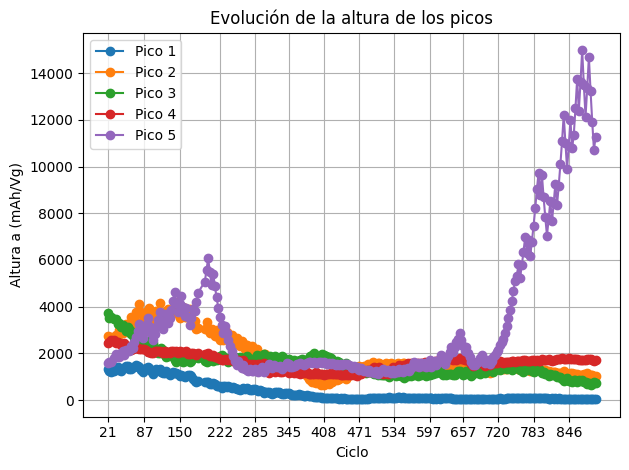

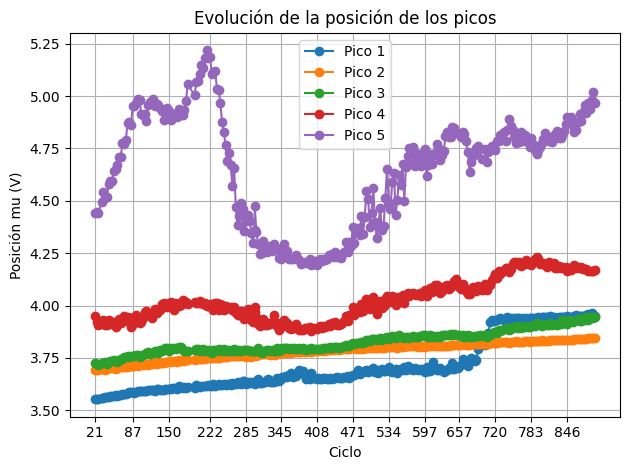

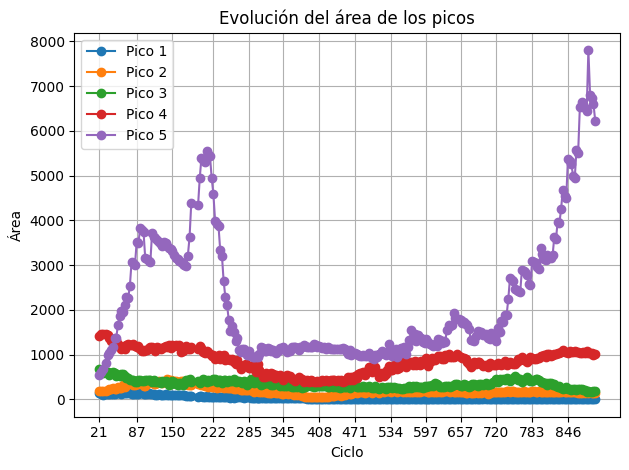

In [76]:
# %% ------------ Graficar evolución de los parámetros con los ciclos  ----------------------------------------

# ------ Elegir de qué loop ---------------
df_final_1 = pd.read_csv("./output/parametros_ajustes_moreSteps-10bounds.csv", index_col=0)
df_final_2 = pd.read_csv("./output/parametros_ajustes_300a600.csv", index_col=0)
df_final_3 = pd.read_csv("./output/parametros_ajustes_600a900.csv", index_col=0)
nombre = '21a900' # etiqueta gráfico
# ------------------------------------------------

df_final=pd.concat([df_final_1, df_final_2, df_final_3])
#df_final = df_final_3

n_peaks = len(p_ini)//3
colors = cm.tab10.colors  # paleta con 10 colores distintos

# Evolución de la altura (a)
plt.figure()
for i in range(n_peaks): # 0,1,2
    plt.plot(df_final.index, df_final[f"a{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("Altura a (mAh/Vg)")
plt.xticks(df_final.index[::21])
plt.title("Evolución de la altura de los picos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_altura_picos_{nombre}.png", dpi=300)
plt.show()

# Evolución de la posición (mu)
plt.figure()
for i in range(n_peaks):
    plt.plot(df_final.index, df_final[f"mu{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("Posición mu (V)")
plt.xticks(df_final.index[::21])
plt.title("Evolución de la posición de los picos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_posicion_picos_{nombre}.png", dpi=300)
plt.show()

# Evolución del área
plt.figure()
for i in range(n_peaks):
    plt.plot(df_final.index, df_final[f"area{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
plt.xlabel("Ciclo")
plt.ylabel("Área")
plt.xticks(df_final.index[::21])
plt.title("Evolución del área de los picos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"./output/evolucion_area_picos_{nombre}.png", dpi=300)
plt.show()

### Grafico un ajuste en particular

[4.21205060e+01 3.94804309e+00 2.34194983e-02 1.01186215e+03
 3.84587878e+00 5.77729806e-02 7.38953163e+02 3.94486176e+00
 9.96294227e-02 1.70222286e+03 4.17108375e+00 2.37713974e-01
 1.12561189e+04 4.96757394e+00 2.20858851e-01 2.47264120e+00
 1.46533209e+02 1.84541676e+02 1.01428748e+03 6.23151170e+03]
5
[4.21205060e+01 3.94804309e+00 2.34194983e-02 1.01186215e+03
 3.84587878e+00 5.77729806e-02 7.38953163e+02 3.94486176e+00
 9.96294227e-02 1.70222286e+03 4.17108375e+00 2.37713974e-01
 1.12561189e+04 4.96757394e+00 2.20858851e-01]


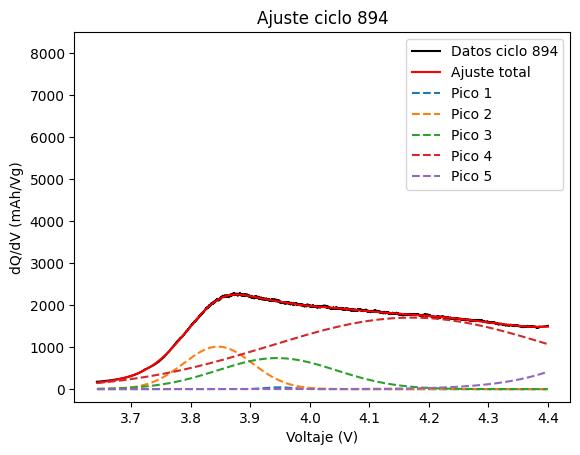

In [80]:
# %% ------------ Graficar ajuste de un ciclo usando lista de parámetros ----------------------------------------

# ------ Elegir cuál y de qué loop ---------------
ciclo = 894
#df_final = pd.read_csv("./output/parametros_ajustes.csv", index_col=0)
#df_final = pd.read_csv("./output/parametros_ajustes_300a600.csv", index_col=0)
df_final = pd.read_csv("./output/parametros_ajustes_600a900.csv", index_col=0)
nombre = '600a900-escaleado' # etiqueta gráfico
# ------------------------------------------------

df_ch = diccio[ciclo]['Ch']
dqdv = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol']

parametros = df_final.loc[ciclo].values
popt = parametros[:n_peaks*3]

print(parametros)
print(n_peaks)
print(popt)

#colors_ciclos = cm.viridis(np.linspace(0, 1, len(indices_ciclos)))
colors_peaks = cm.tab10.colors
#colors_peaks = cm.cool(np.linspace(0, 1, n_peaks))

plt.figure()

y_fit = multi_gauss(V, *popt)
#plt.plot(V, dqdv, color=colors_ciclos[ciclo], label=f"Datos ciclo {ciclo}")
plt.plot(V, dqdv, color='black', label=f"Datos ciclo {ciclo}")
plt.plot(V, y_fit, 'r-', label="Ajuste total")

for i in range(0, len(popt), 3):
    a, mu, sigma = popt[i:i+3]
    j = i // 3   # índice de pico: 0,1,2,...
    plt.plot(V, gauss(V, a, mu, sigma), '--', color=colors_peaks[j % len(colors_peaks)], label=f"Pico {j + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.title(f"Ajuste ciclo {ciclo}")

plt.ylim(-300,8500)



plt.savefig(f'./output/ajuste_picos_ciclo{ciclo}_{nombre}.png', dpi=300)
#plt.close()
plt.show()

### Desde acá, hago ajustes con MENOS picos, ya que algunos se hicieron cero

In [ ]:
# %% ------ Elegir ciclos ------------------------------------------------------------

ciclo_retomar = 300
ciclo_final = 600


excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados_2 = [c for c in ciclos_disponibles if ciclo_retomar <= c <= ciclo_final and c not in excluir]

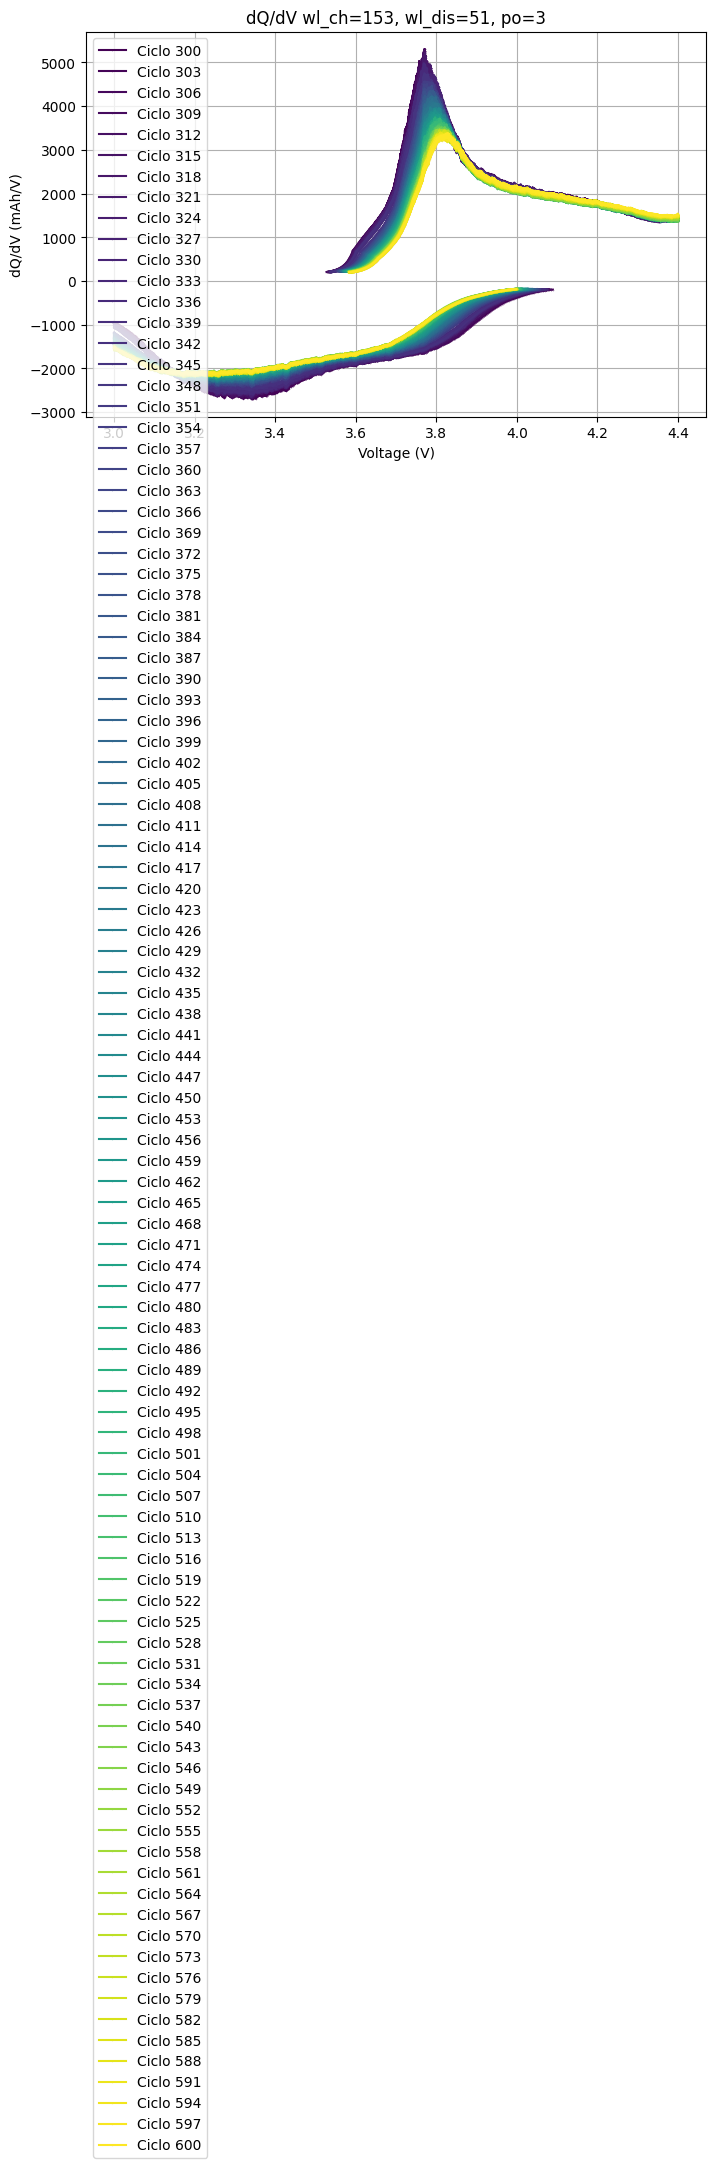

In [ ]:
# %% ------- Trunco datos y calculo derivada ------------------------------------------------------------
diccio_2 = func_deriv.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)
diccio_2 =  func_deriv.plot_dqdv(ciclos_seleccionados, diccio_2)

In [ ]:
parametros = df_final.loc[ciclo_retomar].values

p_ini_2 = [parametros[i:i+3] for i in range(0, n_peaks*3, 3)]

# Quito pico 1
p_ini_2.pop(0)
print(p_ini_2)

[array([4.24225194e+02, 3.74000000e+00, 3.22681344e-02]), array([2.73103204e+03, 3.77733223e+00, 5.12969725e-02]), array([2.25623923e+03, 3.95000000e+00, 2.46005709e-01]), array([8.86733291e+02, 4.38006496e+00, 1.41327456e-01])]


In [ ]:
ciclos = ciclos_seleccionados_2     # los que quieras ajustar
resultados = []             # lista de parámetros ajustados
covs = []                   # lista de matrices de covarianza
areas = []                  # lista de áreas de cada pico

# inicialización con p_ini
p0_actual = p_ini_2
n_peaks_2 = len(p_ini_2)//3

# Realizar ajustes
for ciclo in ciclos:
    try:
        df_ch = diccio_2[ciclo]['Ch']
        V = df_ch['V_ch_savgol']
        dqdv = df_ch['dqdv_ch_calc']

        print(f'Ajustando ciclo {ciclo}...')
        # Ajuste
        popt, pcov = curve_fit(multi_gauss, V, dqdv, p0=p0_actual, bounds=bounds)
    
        # Guardar resultados
        resultados.append(popt)
        covs.append(pcov)
        
        # Calcular áreas de cada gaussiana
        areas_picos = []
        for i in range(0, len(popt), 3):
            a, mu, sigma = popt[i:i+3]
            area = a * sigma * np.sqrt(2*np.pi)
            areas_picos.append(area)
        areas.append(areas_picos)
    
        # Actualizar p0 para el siguiente ciclo
        p0_actual = popt

        # Plot
        if ciclo in ciclos_grafico:
            plt.figure()
            y_fit = multi_gauss(V, *popt)
            plt.plot(V, dqdv, label=f"Datos ciclo {ciclo}")
            plt.plot(V, y_fit, 'r-', label="Ajuste total")

            for i in range(0, len(popt), 3):
                a, mu, sigma = popt[i:i+3]
                j = i // 3   # índice de pico: 0,1,2,...
                plt.plot(V, gauss(V, a, mu, sigma), '--', color=colors[j % len(colors)], label=f"Pico {j + 1}")

            plt.legend()
            plt.xlabel("Voltaje (V)")
            plt.ylabel("dQ/dV (mAh/Vg)")
            plt.title(f"Ajuste ciclo {ciclo}")
            plt.savefig(f'./output/ajuste_picos_ciclo{ciclo}.png', dpi=300)
            plt.close()
    
    except Exception as e:
        # si falla, llenar con NaN
        resultados.append([np.nan,np.nan,np.nan] * n_peaks)
        covs.append(np.full((n_peaks*3, n_peaks*3), np.nan))  # matriz covarianza "vacía"
        areas.append([np.nan] * n_peaks)

# %% ------- Crear DataFrame con parámetros y áreas ------------------------------------------------------------
cols = []
cols_area = []

for i in range(n_peaks):
    cols += [f"a{i+1}", f"mu{i+1}", f"sigma{i+1}"]
    cols_area.append(f"area{i+1}")

df_params = pd.DataFrame(resultados, index=ciclos, columns=cols)
df_areas = pd.DataFrame(areas, index=ciclos, columns=cols_area)
df_final = pd.concat([df_params, df_areas], axis=1)

# Guardar a CSV
df_final.to_csv("./output/parametros_ajustes_segunda-etapa.csv")

print("Ajustes terminados. Resultados guardados en './output/parametros_ajustes.csv'")

Ajustando ciclo 300...
Ajustando ciclo 303...
Ajustando ciclo 306...
Ajustando ciclo 309...
Ajustando ciclo 312...
Ajustando ciclo 315...
Ajustando ciclo 318...
Ajustando ciclo 321...
Ajustando ciclo 324...
Ajustando ciclo 327...
Ajustando ciclo 330...
Ajustando ciclo 333...
Ajustando ciclo 336...
Ajustando ciclo 339...
Ajustando ciclo 342...
Ajustando ciclo 345...
Ajustando ciclo 348...
Ajustando ciclo 351...
Ajustando ciclo 354...
Ajustando ciclo 357...
Ajustando ciclo 360...
Ajustando ciclo 363...
Ajustando ciclo 366...
Ajustando ciclo 369...
Ajustando ciclo 372...
Ajustando ciclo 375...
Ajustando ciclo 378...
Ajustando ciclo 381...
Ajustando ciclo 384...
Ajustando ciclo 387...
Ajustando ciclo 390...
Ajustando ciclo 393...
Ajustando ciclo 396...
Ajustando ciclo 399...
Ajustando ciclo 402...
Ajustando ciclo 405...
Ajustando ciclo 408...
Ajustando ciclo 411...
Ajustando ciclo 414...
Ajustando ciclo 417...
Ajustando ciclo 420...
Ajustando ciclo 423...
Ajustando ciclo 426...
Ajustando c